<div style="background-color:#000047; padding: 30px; border-radius: 10px; color: white; text-align: center;">
    <img src='Figures/alinco_white_text.png' style="height: 100px; margin-bottom: 10px;"/>
    <h1>Módulo 2:  Tareas Clásicas de NLP</h1>
    <h2>Regresión Logística para Análisis de Sentimientos</h2>
</div>


## Introduccion al Análisis de Sentimientos

El **Analisis de Sentimientos** (Sentiment Analysis / Opinion Mining) clasifica el
**tono emocional** de un texto. Es una de las tareas de NLP con mas aplicaciones comerciales.

### Aplicaciones reales:
- **Monitoreo de marca:** deteccion de opinion sobre productos en Twitter
- **E-commerce:** clasificacion automatica de resenas en Amazon, Mercado Libre
- **Finanzas:** sentimiento del mercado en noticias economicas
- **Salud publica:** bienestar emocional en redes sociales
- **Politica:** opinion ciudadana sobre candidatos o politicas publicas

### Niveles de analisis:
```
Nivel documento:  Todo el texto es positivo / negativo / neutro
Nivel oracion:    Cada oracion tiene su propio sentimiento
Nivel aspecto:    'La camara es excelente pero la bateria es mala'
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^  ^^^^^^^^^^^^^^^^^^^^
                   positivo (camara)             negativo (bateria)
```

### Enfoques principales:

| Enfoque | Descripcion | Ventajas | Limitaciones |
|---------|-------------|----------|--------------|
| **Basado en lexicon** | Diccionario con polaridad por palabra | Sin entrenamiento | No capta contexto |
| **Machine Learning** | Naive Bayes, SVM, LR + TF-IDF | Generaliza bien | Necesita datos etiquetados |
| **Deep Learning** | LSTM, BERT | Alta precision | Costoso en recursos |


## Importar librerías y funciones

In [1]:
import nltk
from os import getcwd

In [2]:
# Agregamos la carpeta tmp2 de nuestro espacio de trabajo local, que contiene los archivos de corpus previamente descargados, a la ruta de datos de nltk.
# Esto permite importar estos archivos sin tener que descargarlos de nuevo al actualizar nuestro espacio de trabajo.

filePath = f"{getcwd()}/../tmp2/"
nltk.data.path.append(filePath)

In [3]:
import numpy as np
import pandas as pd
from nltk.corpus import twitter_samples
from utils import process_tweet

### Prepara los datos
* `twitter_samples` contiene subconjuntos de 5,000 tweets positivos, 5,000 tweets negativos y el conjunto completo de 10,000 tweets.
     * Si se utiliza los tres conjuntos de datos, introduciríamos duplicados de los tweets positivos y negativos.
     * Seleccionaremos solo los cinco mil tweets positivos y los cinco mil tweets negativos.

In [4]:
# select the set of positive and negative tweets
nltk.download('twitter_samples')
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     C:\Users\uie70742\AppData\Roaming\nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


In [6]:
len(all_positive_tweets)

5000

In [8]:
all_negative_tweets

['hopeless for tmr :(',
 "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(",
 '@Hegelbon That heart sliding into the waste basket. :(',
 '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too',
 'Dang starting next week I have "work" :(',
 "oh god, my babies' faces :( https://t.co/9fcwGvaki0",
 '@RileyMcDonough make me smile :((',
 '@f0ggstar @stuartthull work neighbour on motors. Asked why and he said hates the updates on search :( http://t.co/XvmTUikWln',
 'why?:("@tahuodyy: sialan:( https://t.co/Hv1i0xcrL2"',
 'Athabasca glacier was there in #1948 :-( #athabasca #glacier #jasper #jaspernationalpark #alberta #explorealberta #… http://t.co/dZZdqmf7Cz',
 "I have a really good m&amp;g idea but I'm never going to meet them :(((",
 '@Rampageinthebox mare ivan :(',
 '@SophiaMascardo happy trip, keep safe. see you soon :* :(',
 "I'm so tired hahahah :(",
 '@GrumpyCockney With knee replacements they get you up &amp; about the same day. :-(   Ou

In [7]:
len(all_negative_tweets)

5000

* Train test split: 20% para test, y 80% para train.


In [10]:
# Dividir los datos en dos partes, una para entrenamiento y otra para pruebas (conjunto de validación).
train_pos=all_positive_tweets[:4000]
test_pos=all_positive_tweets[4000:]

train_neg=all_negative_tweets[:4000]
test_neg=all_negative_tweets[4000:]


In [11]:
train_x = train_pos + train_neg
len(train_x)

8000

In [12]:
test_x = test_pos + test_neg
len(test_x)

2000

In [16]:
np.ones((len(train_pos),1)), np.zeros((len(train_neg),1))

(array([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [1.]], shape=(4000, 1)),
 array([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], shape=(4000, 1)))

In [17]:
train_y = np.append(np.ones((len(train_pos),1)), np.zeros((len(train_neg),1)), axis=0)
test_y = np.append(np.ones((len(test_pos),1)), np.zeros((len(test_neg),1)), axis=0)


In [19]:
len(train_y),len(test_y) 

(8000, 2000)

In [20]:
def build_freqs(tweets, ys):

    yslist = np.squeeze(ys).tolist()

    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1
    return freqs

In [21]:
#Descargaar los stopwords
nltk.download('stopwords')

# Creaamos el diccionario de frecuencias
freqs = build_freqs(train_x, train_y)
freqs

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\uie70742\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{('followfriday', 1.0): 23,
 ('top', 1.0): 30,
 ('engag', 1.0): 7,
 ('member', 1.0): 14,
 ('commun', 1.0): 27,
 ('week', 1.0): 72,
 (':)', 1.0): 2847,
 ('hey', 1.0): 60,
 ('jame', 1.0): 7,
 ('odd', 1.0): 2,
 (':/', 1.0): 5,
 ('pleas', 1.0): 80,
 ('call', 1.0): 27,
 ('contact', 1.0): 4,
 ('centr', 1.0): 1,
 ('02392441234', 1.0): 1,
 ('abl', 1.0): 6,
 ('assist', 1.0): 1,
 ('mani', 1.0): 28,
 ('thank', 1.0): 504,
 ('listen', 1.0): 14,
 ('last', 1.0): 39,
 ('night', 1.0): 55,
 ('bleed', 1.0): 2,
 ('amaz', 1.0): 41,
 ('track', 1.0): 5,
 ('scotland', 1.0): 2,
 ('congrat', 1.0): 15,
 ('yeaaah', 1.0): 1,
 ('yipppi', 1.0): 1,
 ('accnt', 1.0): 2,
 ('verifi', 1.0): 2,
 ('rqst', 1.0): 1,
 ('succeed', 1.0): 1,
 ('got', 1.0): 57,
 ('blue', 1.0): 8,
 ('tick', 1.0): 1,
 ('mark', 1.0): 1,
 ('fb', 1.0): 4,
 ('profil', 1.0): 2,
 ('15', 1.0): 4,
 ('day', 1.0): 187,
 ('one', 1.0): 90,
 ('irresist', 1.0): 2,
 ('flipkartfashionfriday', 1.0): 16,
 ('like', 1.0): 187,
 ('keep', 1.0): 55,
 ('love', 1.0): 336,
 

In [22]:
len(freqs)

11307

### Procesamiento del tweet

La función dada en la librería `utils`, `process_tweet ()` tokeniza el tweet en palabras individuales, elimina los stopwords, aplica steammer, normalizacion y tokenización.

In [23]:
# Probemos la función
process_tweet(train_x[0])

['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)']

##  Extrayendo las características

* Dada una lista de tweets, necesitamos extraer algunas características y guárdelas en una matriz. Extraeremos dos características.
     * La primera característica es la cantidad de palabras positivas en un tweet.
     * La segunda característica es la cantidad de palabras negativas en un tweet.
* Luego entrenaremos un clasificador de regresión logística con estas características.
* Luego, probaremos el clasificador en un conjunto de validación (test).

### Implementación de la función de extract_features.
* Esta función admite un solo tweet.
* Procesaremos el tweet usando la función `process_tweet()` importada y la guardaremos en la lista de palabras del tweet.
* Recorreremos cada palabra en la lista de palabras procesadas
     * Para cada palabra, consultaremos el diccionario `freqs` para el recuento cuando esa palabra tiene una etiqueta positiva '1'. (con clave `(palabra, 1.0)`
     * Haremos lo mismo con el recuento para cuando la palabra esté asociada con la etiqueta negativa '0'. (con la clave `(palabra, 0.0)`.)


In [24]:
def extract_features(tweet, freqs):
   
    # process_tweet tokenizacion, stems, y removiendo stopwords
    word_l = process_tweet(tweet)
    # 3 elementos in la forma de 1 x 3 vector
    x = np.zeros((1,3))
    #El bias se setea a 1
    x[0,0] = 1
    
    # Recorremos las palabraas sobre la lista de palabras
    for word in word_l:
        x[0,1] += freqs.get((word,1.0),0) 
        x[0,2] += freqs.get((word,0.0),0) 
        
    return x

In [25]:
#test 1:
# Probando la función
extract_features(train_x[0], freqs)

array([[1.00e+00, 3.02e+03, 6.10e+01]])

In [26]:
# test 2:
# Probando una palabraa que no se encuentre en el diccionario de freeqs freqs dictionary
extract_features('blorb bleeb bloo', freqs)

array([[1., 0., 0.]])

# Implementación de la Regresión Logística


### Función sigmoide
Aprenderá a utilizar la regresión logística para la clasificación de texto.
* La función sigmoidea se define como:

$$ h(z) = \frac{1}{1+\exp^{-z}} \tag{1}$$

Asigna la entrada 'z' a un valor que varía entre 0 y 1, por lo que puede tratarse como una probabilidad.


In [27]:
def sigmoid(z):
    # Calculando la función sigmoide
    h = 1 / (1 + np.exp(-z))
    return h

### Regresión Logísticaa: regression y función sigmoide

La regresión logística toma una regresión lineal regular y aplica un sigmoide a la salida de la regresión lineal.

Regresion:
$$z = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + ... \theta_N x_N$$
Tenga en cuenta que los valores $ \theta $ son "pesos". Si realizó la especialización en aprendizaje profundo, nos referimos a los pesos con el vector `w`. En este curso, usamos una variable diferente $ \theta $ para referirnos a los pesos.

Regresión logística
$$ h(z) = \frac{1}{1+\exp^{-z}}$$
$$z = \theta_0 x_0 + \theta_1 x_1 + \theta_2 x_2 + ... \theta_N x_N$$
Nos referiremos a `z` como los 'logits'.

### Función de costo y gradiente

La función de costo utilizada para la regresión logística es el promedio de la pérdida de registro en todos los ejemplos de entrenamiento:

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^m y^{(i)}\log (h(z(\theta)^{(i)})) + (1-y^{(i)})\log (1-h(z(\theta)^{(i)}))\tag{5} $$
* $m$ es la cantidad de ejemplos de entrenamiento
* $y^{(i)}$ es la etiqueta real del i-ésimo dato de entrenamiento.
* $h(z(\theta)^{(i)})$ es la predicción del modelo para el i-ésimo ejemplo de entrenamiento.

La función de pérdida para un solo ejemplo de entrenamiento es
$$ Loss = -1 \times \left( y^{(i)}\log (h(z(\theta)^{(i)})) + (1-y^{(i)})\log (1-h(z(\theta)^{(i)})) \right)$$

* Todos los valores de $ h $ están entre 0 y 1, por lo que los registros serán negativos. Esa es la razón del factor -1 aplicado a la suma de los dos términos de pérdida.
* Tenga en cuenta que cuando el modelo predice 1 ($ h (z (\theta)) = 1 $) y la etiqueta $ y $ también es 1, la pérdida para ese ejemplo de entrenamiento es 0.
* De manera similar, cuando el modelo predice 0 ($ h (z (\theta)) = 0 $) y la etiqueta real también es 0, la pérdida para ese ejemplo de entrenamiento es 0.
* Sin embargo, cuando la predicción del modelo es cercana a 1 ($ h (z (\theta)) = 0.9999 $) y la etiqueta es 0, el segundo término de la pérdida logarítmica se convierte en un gran número negativo, que luego se multiplica por el factor general de -1 para convertirlo en un valor de pérdida positivo. $ -1 \times (1 - 0) \times log (1 - 0.9999) \approx 9.2 $ Cuanto más se acerque la predicción del modelo a 1, mayor será la pérdida.

* Del mismo modo, si el modelo predice cerca de 0 ($ h (z) = 0.0001 $) pero la etiqueta real es 1, el primer término en la función de pérdida se convierte en un número grande: $ -1 \times log (0.0001) \approx 9.2 $. Cuanto más cercana sea la predicción a cero, mayor será la pérdida.

#### Actualizar los pesos

Para actualizar su vector de peso $ \theta $, aplicará el descenso de gradiente para mejorar iterativamente las predicciones de su modelo.
El gradiente de la función de costo $ J $ con respecto a uno de los pesos $ \theta_j $ es:

$$\nabla_{\theta_j}J(\theta) = \frac{1}{m} \sum_{i=1}^m(h^{(i)}-y^{(i)})x_j \tag{5}$$
* 'i' es el índice de todos los ejemplos de formación "m".
* 'j' es el índice del peso $ \theta_j $, entonces $ x_j $ es la característica asociada con el peso $ \theta_j $

* Para actualizar el peso $ \theta_j $, lo ajustamos restando una fracción del gradiente determinado por $ \alpha $:
$$ \theta_j = \theta_j - \alpha \times \nabla_{\theta_j} J (\theta) $$
* La tasa de aprendizaje $ \alpha $ es un valor que elegimos para controlar qué tan grande será una sola actualización.


## Implementación de la función Gradiente Descendente
* El número de iteraciones `num_iters` es el número de veces que utilizará todo el conjunto de entrenamiento.
* Para cada iteración, calculará la función de costo usando todos los ejemplos de entrenamiento (hay ejemplos de entrenamiento `m`), y para todas las funciones.
* En lugar de actualizar un solo peso $ \theta_i $ a la vez, podemos actualizar todos los pesos en el vector de columna:  
$$\mathbf{\theta} = \begin{pmatrix}
\theta_0
\\
\theta_1
\\
\theta_2
\\
\vdots
\\
\theta_n
\end{pmatrix}$$
* $ \mathbf {\theta} $ tiene dimensiones (n + 1, 1), donde 'n' es el número de características, y hay un elemento más para el término de sesgo $ \theta_0 $ (tenga en cuenta que el valor de característica correspondiente $ \mathbf {x_0} $ es 1).
* Los 'logits', 'z', se calculan multiplicando la matriz de características 'x' con el vector de peso 'theta'.  $z = \mathbf{x}\mathbf{\theta}$
    * $\mathbf{x}$ has dimensions (m, n+1)
    * $\mathbf{\theta}$: has dimensions (n+1, 1)
    * $\mathbf{z}$: has dimensions (m, 1)
* La predicción 'h' se calcula aplicando el sigmoide a cada elemento en 'z': $ h (z) = sigmoid (z) $, y tiene dimensiones (m, 1).
* La función de costo $ J $ se calcula tomando el producto escalar de los vectores 'y' y 'log (h)'. Dado que tanto 'y' como 'h' son vectores de columna (m, 1), transponga el vector a la izquierda, de modo que la multiplicación de matrices de un vector de fila con un vector de columna realice el producto escalar.
$$J = \frac{-1}{m} \times \left(\mathbf{y}^T \cdot log(\mathbf{h}) + \mathbf{(1-y)}^T \cdot log(\mathbf{1-h}) \right)$$
* La actualización de theta también está vectorizada. Debido a que las dimensiones de $ \mathbf {x} $ son (m, n + 1), y tanto $ \mathbf {h} $ como $ \mathbf {y} $ son (m, 1), necesitamos transponer $ \mathbf {x} $ y colóquelo a la izquierda para realizar la multiplicación de matrices, que luego da la respuesta (n + 1, 1) que necesitamos:
$$\mathbf{\theta} = \mathbf{\theta} - \frac{\alpha}{m} \times \left( \mathbf{x}^T \cdot \left( \mathbf{h-y} \right) \right)$$

In [28]:
def gradientDescent(x, y, theta, alpha, num_iters):
    m = x.shape[0]

    for i in range(0, num_iters):
        z = np.dot(x,theta)
        h = sigmoid(z)

        # calculando la función de costo
        J = -1./m * (np.dot(y.transpose(), np.log(h)) + np.dot((1-y).transpose(),np.log(1-h)))

        # Actualizando los pesos del modelo
        theta = theta = theta - (alpha/m) * np.dot(x.transpose(),(h-y))

    
    J = float(J)
    return J, theta

### 1.- Entrenar el modelo de Análsis de Sentimientos

* Apilaremos las características de todos los datos de entrenamiento en una matriz `X`.
* Llamaremos la función `gradientDescent`, que se implementó anteriormente.



In [29]:
# Crearemos la matrix 'X' (datos de entrada) y vamos a extraer las frecuencias de los tweets (modelo BOW conteo de frecuencias)
X = np.zeros((len(train_x), 3))
for i in range(len(train_x)):
    X[i, :] = extract_features(train_x[i], freqs)
# Asignando a Y las etiquetas de salida
Y = train_y

# Aplicando el gradient descent



In [31]:
X.shape, Y.shape

((8000, 3), (8000, 1))

In [32]:
J, theta = gradientDescent(X, Y, np.zeros((3,1)), 1e-9, 1500)

C:\Users\uie70742\AppData\Local\Temp\ipykernel_33936\1379006294.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J = float(J)


In [33]:
J

0.24217171919630215

In [34]:
theta

array([[ 7.19010257e-08],
       [ 5.23517158e-04],
       [-5.55794174e-04]])

### 2.- Probando la regresión logística

**Instrucciones para Predecir si un tweet es positivo o negativo**

* Dado un tweet, tendremos que procesarlo y luego extraer las características.
* Aplicaremos los pesos aprendidos del modelo para obtener los logits.
* Aplicaremos la función sigmoide a los logits para obtener la predicción (un valor entre 0 y 1).

$$y_{pred} = sigmoid(\mathbf{x} \cdot \theta)$$

In [35]:
# UNQ_C4 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)
def predict_tweet(tweet, freqs, theta):
   
    # extraer los features del tweet
    x = extract_features(tweet,freqs)

    # Hacer una predicción con theta (parámetros ya entrenados)
    y_pred = sigmoid(np.dot(x,theta))

    return y_pred

In [37]:
#Probar el modelo
test_tweet = ['I am happy', 'I am bad', 'this movie should have been great.', 'great', 'great great', 'great great great', 'great great great great']

predict_tweet('I am happy', freqs, theta)

array([[0.51856198]])

In [38]:
for tweet in test_tweet:
    print(f'tweet: {tweet} \t predicción: {predict_tweet(tweet, freqs, theta)}')

tweet: I am happy 	 predicción: [[0.51856198]]
tweet: I am bad 	 predicción: [[0.49432935]]
tweet: this movie should have been great. 	 predicción: [[0.51531165]]
tweet: great 	 predicción: [[0.5154487]]
tweet: great great 	 predicción: [[0.53086791]]
tweet: great great great 	 predicción: [[0.5462284]]
tweet: great great great great 	 predicción: [[0.56150139]]


### 3.- Verificando el rendimiento del modelo

Después de entrenar el modelo con el conjunto de entrenamiento anterior, verificaremos cómo podría funcionar el modelo en datos reales no vistos probándolo con el conjunto de prueba.

**Implementar `test_logistic_regression`**

* Dados los datos de prueba y los pesos del modelo entrenado, calcularemos la precisión del modelo de regresión logística.
* Utilizaremos la función `predict_tweet ()` para hacer predicciones en cada tweet en el conjunto de prueba.
* Si la predicción es> 0,5, diremos que la clasificación del modelo `y_hat` es 1; de lo contrario, la clasificación del modelo` y_hat` será en 0.
* Una predicción es precisa cuando `y_hat` es igual a` test_y`. Para calcular la precisón sumaremos todas las instancias en las que ($y_hat==test_y$) sean iguales y divida por `m`.


In [39]:
# UNQ_C5 (UNIQUE CELL IDENTIFIER, DO NOT EDIT)None
def test_logistic_regression(test_x, test_y, freqs, theta):
   
    y_hat = []

    for tweet in test_x:
        
        y_pred = predict_tweet(tweet, freqs, theta)

        if y_pred > 0.5:
            y_hat.append(1)
        else:
            y_hat.append(0)
    accuracy = (y_hat==np.squeeze(test_y)).sum()/len(test_x)
    return accuracy

In [42]:
test_logistic_regression(test_x, test_y, freqs, theta)

np.float64(0.9965)

### Clase completa para Regresion Logística para Análisis de Sentimientos

In [45]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class RegresionLogisticaSentimiento:
    """Regresion logistica binaria con gradiente descendente batch."""

    def __init__(self, lr=0.1, epochs=500, lambda_=0.01, umbral=0.5):
        self.lr = lr; self.epochs = epochs
        self.lambda_ = lambda_; self.umbral = umbral
        self.w = None; self.b = 0.0; self.historial = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _perdida(self, y_hat, y):
        eps = 1e-15
        y_hat = np.clip(y_hat, eps, 1 - eps)
        ce = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
        return ce + (self.lambda_ / 2) * np.dot(self.w, self.w)

    def fit(self, X, y, verbose=True):
        N, D = X.shape
        self.w = np.zeros(D); self.b = 0.0; self.historial = []
        for epoch in range(self.epochs):
            y_hat = self._sigmoid(X.dot(self.w) + self.b)
            loss = self._perdida(y_hat, y)
            self.historial.append(loss)
            error = y_hat - y
            grad_w = X.T.dot(error) / N + self.lambda_ * self.w
            grad_b = np.mean(error)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            if verbose and (epoch % 100 == 0 or epoch == self.epochs - 1):
                acc = accuracy_score(y, self.predecir(X))
                print(f"  Epoch {epoch:4d} | Perdida: {loss:.4f} | Acc train: {acc:.4f}")
        return self

    def predecir_proba(self, X):
        return self._sigmoid(X.dot(self.w) + self.b)

    def predecir(self, X):
        return (self.predecir_proba(X) >= self.umbral).astype(int)

    def palabras_importantes(self, vocab, top_n=10):
        idx_pos = np.argsort(self.w)[::-1][:top_n]
        idx_neg = np.argsort(self.w)[:top_n]
        return [(vocab[i], self.w[i]) for i in idx_pos], [(vocab[i], self.w[i]) for i in idx_neg]

print("Clase RegresionLogisticaSentimiento lista.")


Clase RegresionLogisticaSentimiento lista.


In [46]:
datos = [
    # POSITIVOS espanol (10)
    ("La pelicula fue increible, me encanto cada escena del film", "positivo"),
    ("El producto supero mis expectativas, excelente calidad precio", "positivo"),
    ("Servicio fantastico, personal muy amable y eficiente siempre", "positivo"),
    ("La comida estaba deliciosa, sabores perfectos y bien presentada", "positivo"),
    ("Muy feliz con la compra, llego rapido y en perfectas condiciones", "positivo"),
    ("El libro es fascinante, no pude dejarlo, muy recomendable", "positivo"),
    ("La app funciona perfecto, intuitiva, rapida y sin errores", "positivo"),
    ("Increible experiencia, el mejor viaje de mi vida sin duda alguna", "positivo"),
    ("Excelente atencion, personal cordial, profesional y comprometido", "positivo"),
    ("Me encanto el hotel, habitaciones limpias, comodas y modernas", "positivo"),
    # NEGATIVOS espanol (10)
    ("Terrible experiencia, jamas volvere a comprar en este lugar horrible", "negativo"),
    ("El producto llego roto y tardaron semanas en responder el reclamo", "negativo"),
    ("Pesima atencion, muy groseros, indiferentes y sin solucion alguna", "negativo"),
    ("La pelicula fue un desperdicio de tiempo y dinero, muy mala", "negativo"),
    ("Muy decepcionante, no cumple nada de lo que promete el vendedor", "negativo"),
    ("Comida fria, horrible sabor y servicio muy lento e indiferente", "negativo"),
    ("Servicio lentisimo, espere dos horas sin ninguna respuesta util", "negativo"),
    ("La app tiene muchos errores criticos y se cierra sola sin aviso", "negativo"),
    ("No recomiendo este lugar, muy sucio, peligroso y extremadamente caro", "negativo"),
    ("El hotel fue una pesadilla total, jamas volvere por nada del mundo", "negativo"),
    # NEUTROS espanol (10)
    ("El producto funciona bien, nada especial pero cumple su funcion", "neutro"),
    ("La pelicula estuvo bien, ni muy buena ni mala, entretenida", "neutro"),
    ("El servicio fue normal, dentro de lo esperado para el precio dado", "neutro"),
    ("La entrega llego en el tiempo estimado sin problemas ni novedad", "neutro"),
    ("El libro trata temas interesantes aunque algunos capitulos son lentos", "neutro"),
    ("El restaurante tiene buena ubicacion y precios razonables", "neutro"),
    ("El hotel esta bien ubicado pero las habitaciones son basicas", "neutro"),
    ("La app hace lo que dice, sin problemas ni sorpresas especiales", "neutro"),
    ("La calidad es aceptable para el rango de precio que tiene el producto", "neutro"),
    ("El ambiente era agradable aunque el servicio tardo un poco mas", "neutro"),
    # POSITIVOS ingles (5)
    ("Absolutely amazing product, exceeded all my expectations by far", "positivo"),
    ("Outstanding service, very professional staff and quick response", "positivo"),
    ("Best experience ever, will definitely recommend to all my friends", "positivo"),
    ("Fantastic quality, arrived quickly and exactly as described online", "positivo"),
    ("Wonderful atmosphere, excellent food and very attentive service", "positivo"),
    # NEGATIVOS ingles (5)
    ("Terrible product, broke after two days, complete waste of money", "negativo"),
    ("Horrible experience, rude staff and nothing worked as expected", "negativo"),
    ("Do NOT buy this, worst purchase I have ever made in my life", "negativo"),
    ("Awful service, waited for hours with no response or solution", "negativo"),
    ("Disgusting quality, very disappointing and overpriced product", "negativo"),
]

textos    = [d[0] for d in datos]
etiquetas = [d[1] for d in datos]
df = pd.DataFrame({"texto": textos, "sentimiento": etiquetas})

print(f"Corpus: {len(df)} resenas")
print(df["sentimiento"].value_counts().to_string())
print()
for _, row in df.sample(4, random_state=1).iterrows():
    print(f"  [{row["sentimiento"]:<10}] {row["texto"][:60]}")


Corpus: 40 resenas
sentimiento
positivo    15
negativo    15
neutro      10

  [positivo  ] Servicio fantastico, personal muy amable y eficiente siempre
  [positivo  ] Outstanding service, very professional staff and quick respo
  [positivo  ] La comida estaba deliciosa, sabores perfectos y bien present
  [neutro    ] La pelicula estuvo bien, ni muy buena ni mala, entretenida


In [47]:
# Datos binarios (positivo=1, negativo=0, descartamos neutro)
datos_bin = [(t, l) for t, l in zip(textos, etiquetas) if l != 'neutro']
textos_bin = [d[0] for d in datos_bin]
y_bin = np.array([1 if d[1] == 'positivo' else 0 for d in datos_bin])
print(f"Positivos: {y_bin.sum()}  Negativos: {(1-y_bin).sum()}  Total: {len(y_bin)}")

# Vectorizacion TF-IDF
tfidf_lr = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, min_df=1)
X_bin = tfidf_lr.fit_transform(textos_bin).toarray()
vocab_lr = tfidf_lr.get_feature_names_out()

X_tr, X_te, y_tr, y_te = train_test_split(
    X_bin, y_bin, test_size=0.25, random_state=42, stratify=y_bin)
print(f"Train: {len(X_tr)}  Test: {len(X_te)}")

print()
print("Entrenando Regresion Logistica desde cero...")
print("=" * 55)
rl = RegresionLogisticaSentimiento(lr=0.3, epochs=500, lambda_=0.01)
rl.fit(X_tr, y_tr, verbose=True)


Positivos: 15  Negativos: 15  Total: 30
Train: 22  Test: 8

Entrenando Regresion Logistica desde cero...
  Epoch    0 | Perdida: 0.6931 | Acc train: 1.0000
  Epoch  100 | Perdida: 0.5040 | Acc train: 1.0000
  Epoch  200 | Perdida: 0.4494 | Acc train: 1.0000
  Epoch  300 | Perdida: 0.4327 | Acc train: 1.0000
  Epoch  400 | Perdida: 0.4274 | Acc train: 1.0000
  Epoch  499 | Perdida: 0.4257 | Acc train: 1.0000


REPORTE EN CONJUNTO DE PRUEBA
              precision    recall  f1-score   support

    negativo       0.40      0.50      0.44         4
    positivo       0.33      0.25      0.29         4

    accuracy                           0.38         8
   macro avg       0.37      0.38      0.37         8
weighted avg       0.37      0.38      0.37         8



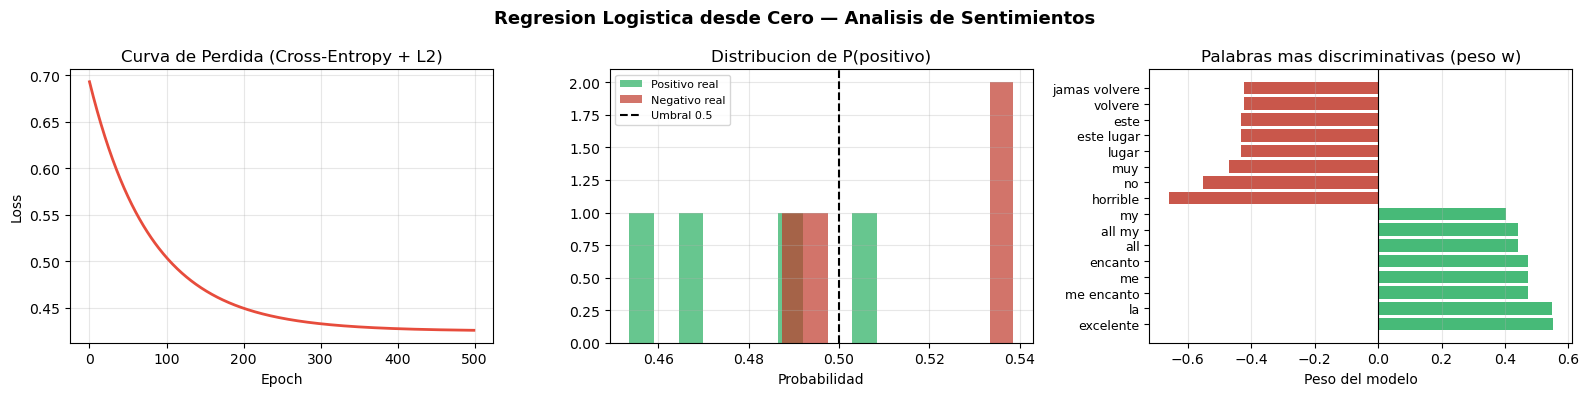

In [48]:
# --- Evaluacion ---
y_pred_bin  = rl.predecir(X_te)
y_proba_bin = rl.predecir_proba(X_te)

print("REPORTE EN CONJUNTO DE PRUEBA")
print("=" * 55)
print(classification_report(y_te, y_pred_bin, target_names=['negativo', 'positivo']))

# --- Visualizacion: 3 paneles ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Regresion Logistica desde Cero — Analisis de Sentimientos',
             fontsize=13, fontweight='bold')

# 1. Curva de perdida
axes[0].plot(rl.historial, color='#e74c3c', linewidth=2)
axes[0].set_title('Curva de Perdida (Cross-Entropy + L2)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

# 2. Distribucion de probabilidades
axes[1].hist(y_proba_bin[y_te == 1], bins=10, alpha=0.7, color='#27ae60', label='Positivo real')
axes[1].hist(y_proba_bin[y_te == 0], bins=10, alpha=0.7, color='#c0392b', label='Negativo real')
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[1].set_title('Distribucion de P(positivo)')
axes[1].set_xlabel('Probabilidad'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# 3. Palabras mas discriminativas
positivas, negativas = rl.palabras_importantes(vocab_lr, top_n=8)
all_words   = [w for w, _ in positivas] + [w for w, _ in negativas]
all_weights = [s for _, s in positivas] + [s for _, s in negativas]
colors_bar  = ['#27ae60'] * len(positivas) + ['#c0392b'] * len(negativas)
axes[2].barh(range(len(all_words)), all_weights, color=colors_bar, alpha=0.85)
axes[2].set_yticks(range(len(all_words)))
axes[2].set_yticklabels(all_words, fontsize=9)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Palabras mas discriminativas (peso w)')
axes[2].set_xlabel('Peso del modelo'); axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()